# Entregável 2 — Workflow, ReAct, Memória e Integrações

> **Grupo:** Mariana Aparecida Ferreira, Vinicius Luis Belem Bronzatti
> **Tema/Projeto:** RiskOps — Sistema Multiagente para Gestão Automatizada do Ciclo de Vida de Regras de Risco
> **Data:** 09/09/2026

Este notebook estende o baseline funcional do Entregável 1 para uma versão agêntica com fluxo
de controle explícito, uso de ferramentas e gerenciamento de contexto.


# A. Estrutura herdada do Entregável 1

Reunidos aqui, sem alteração: o pacote `riskops` (schema/registro de regras, avaliador,
métricas de backtest, e a lógica do baseline do E1 -- schema `RuleAssessment`, prompt,
veredito de referência, verificação -- promovida em `riskops.diagnostics` no início deste
entregável, precisamente para poder ser reaproveitada aqui sem cópia/colagem), a amostra do
BAF, o registro de regras, o conjunto de casos congelado `test_cases` (T01-T10, idêntico ao
E1) e o `RUN_INFO`.

O baseline (v1) será **reexecutado nesta entrega**, com o mesmo modelo e mesmo ambiente da v2
(Seção F) -- não reaproveitamos os números do E1 de uma semana atrás.


In [1]:
!git clone --depth 1 https://github.com/bronzattivinicius/riskops.git riskops_repo
%pip install -q -U langchain-groq pydantic pandas


Cloning into 'riskops_repo'...


remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (44/44), done.


remote: Total 56 (delta 5), reused 41 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 1.85 MiB | 21.80 MiB/s, done.
Resolving deltas: 100% (5/5), done.


Note: you may need to restart the kernel to use updated packages.


In [2]:
# O pacote riskops eh Python puro, entao apontamos o interpretador direto para o
# codigo-fonte clonado -- evita a necessidade de reiniciar o kernel apos uma instalacao
# editavel via pip (ver Entregavel 1, Secao 11, para o motivo).
import sys

sys.path.insert(0, "riskops_repo/src")

import riskops

print("riskops importado de:", riskops.__file__)


riskops importado de: /Users/viniciusbronzatti/Downloads/riskops/riskops_repo/src/riskops/__init__.py


In [3]:
import os, getpass, datetime, platform

os.environ["LANGCHAIN_TRACING_V2"] = "false"
os.environ["LANGSMITH_TRACING"] = "false"

def carregar_chave_groq() -> str:
    """Carrega a GROQ_API_KEY sem jamais escreve-la neste notebook."""
    if os.environ.get("GROQ_API_KEY"):
        return "variavel de ambiente"
    try:
        from google.colab import userdata          # noqa: F401
        os.environ["GROQ_API_KEY"] = userdata.get("INF0093-2026-2S")
        return "Colab userdata"
    except Exception:
        os.environ["GROQ_API_KEY"] = getpass.getpass("GROQ_API_KEY: ")
        return "entrada manual"

origem = carregar_chave_groq()
assert os.environ.get("GROQ_API_KEY"), "Chave nao configurada."
print("Chave carregada via:", origem)


Chave carregada via: variavel de ambiente


In [4]:
from langchain_groq import ChatGroq
from riskops.diagnostics import RuleAssessment

MODEL_NAME = "openai/gpt-oss-20b"   # o mesmo modelo do Entregavel 1 -- nao trocar
TEMPERATURE = 0
PROMPT_VERSAO_BASELINE = "v1"        # prompt do diagnostico de uma regra, inalterado desde o E1
PROMPT_VERSAO_AGENTE = "v2-agente-v1"  # nova instrucao de sistema do passo agentic (Secao C)

llm = ChatGroq(model=MODEL_NAME, temperature=TEMPERATURE)
structured_llm = llm.with_structured_output(RuleAssessment, include_raw=True)

RUN_INFO = {
    "modelo": MODEL_NAME,
    "temperatura": TEMPERATURE,
    "prompt_versao_baseline": PROMPT_VERSAO_BASELINE,
    "prompt_versao_agente": PROMPT_VERSAO_AGENTE,
    "data": datetime.datetime.now().isoformat(timespec="seconds"),
    "python": platform.python_version(),
}
RUN_INFO


{'modelo': 'openai/gpt-oss-20b',
 'temperatura': 0,
 'prompt_versao_baseline': 'v1',
 'prompt_versao_agente': 'v2-agente-v1',
 'data': '2026-09-09T10:13:48',
 'python': '3.12.14'}

In [5]:
from pathlib import Path
from riskops.data.loader import load_baf
from riskops.rules.store import RuleStore

REPO_DIR = Path("riskops_repo")
df = load_baf(path=REPO_DIR / "data" / "sample" / "baf_sample.csv")
store = RuleStore(root=REPO_DIR / "rule_registry")

print(f"{len(df)} transacoes carregadas | taxa de fraude na amostra: {df['fraud_bool'].mean():.2%}")
print(f"{len(store.list_rule_ids())} regras no registro: {store.list_rule_ids()}")


20000 transacoes carregadas | taxa de fraude na amostra: 1.10%
8 regras no registro: ['baf_device_email_reuse', 'baf_foreign_request', 'baf_free_email_domain', 'baf_high_credit_risk_score', 'baf_high_velocity_6h', 'baf_impossible_threshold', 'baf_invalid_phone_combo', 'baf_weak_identity_match_elevated_risk']


Conjunto de casos congelado, **idêntico ao Entregável 1** (T01-T10; nenhum caso foi
modificado ou removido). A impressão digital abaixo prova isso -- substitui o utilitário do
suplemento da disciplina, que não estava disponível para este grupo.


In [6]:
test_cases = [
    {"id": "T01", "rule_id": "baf_foreign_request", "tipo": "normal", "verificacao": "auto"},
    {"id": "T02", "rule_id": "baf_free_email_domain", "tipo": "normal", "verificacao": "auto"},
    {"id": "T03", "rule_id": "baf_high_velocity_6h", "tipo": "normal", "verificacao": "auto"},
    {"id": "T04", "rule_id": "baf_high_credit_risk_score", "tipo": "normal", "verificacao": "auto"},
    {"id": "T05", "rule_id": "baf_weak_identity_match_elevated_risk", "tipo": "normal", "verificacao": "auto"},
    {"id": "T06", "rule_id": "baf_device_email_reuse", "tipo": "normal", "verificacao": "auto"},
    {"id": "T07", "rule_id": "baf_invalid_phone_combo", "tipo": "ambiguo", "verificacao": "manual"},
    {"id": "T08", "rule_id": "baf_impossible_threshold", "tipo": "zero-match", "verificacao": "auto"},
    {"id": "T09", "rule_id": "regra_fantasma", "tipo": "informacao ausente", "verificacao": "auto"},
    {"id": "T10", "rule_id": "", "tipo": "entrada incompleta", "verificacao": "auto"},
]

from riskops.diagnostics import impressao_digital_casos

fingerprint_e2 = impressao_digital_casos(test_cases)
print(len(test_cases), "casos definidos.")
print("impressao digital do conjunto (E2):", fingerprint_e2)

# Verificacao real, nao apenas uma afirmacao em texto: a funcao de impressao digital
# nao existia ainda quando o E1 foi executado, entao nao ha um valor ja registrado la
# para comparar. Em vez disso, carregamos o test_cases direto do notebook do E1 (ja
# clonado acima) e comparamos as impressoes digitais aqui, agora.
import json as _json

with open(REPO_DIR / "E1_Ferreira_Bronzatti.ipynb", encoding="utf-8") as _f:
    _nb_e1 = _json.load(_f)
_src_e1 = next("".join(c["source"]) for c in _nb_e1["cells"] if "test_cases = [" in "".join(c["source"]))
_ns = {}
exec(compile(_src_e1.split("from riskops.diagnostics")[0], "<e1_test_cases>", "exec"), _ns)
fingerprint_e1 = impressao_digital_casos(_ns["test_cases"])

print("impressao digital do conjunto (E1):", fingerprint_e1)
assert fingerprint_e1 == fingerprint_e2, "o conjunto de casos mudou entre o E1 e o E2!"
print("OK: conjunto de teste identico entre E1 e E2, verificado por comparacao direta (nao so por afirmacao).")


10 casos definidos.
impressao digital do conjunto (E2): 6a0882f65d4c1637
10 casos definidos.
impressao digital do conjunto (E1): 6a0882f65d4c1637
OK: conjunto de teste identico entre E1 e E2, verificado por comparacao direta (nao so por afirmacao).


Funções de verificação e critérios de sucesso, reaproveitados sem alteração de
`riskops.diagnostics` (`veredito_referencia`, `metrica_citada`, `verificar_caso`).


In [7]:
from riskops.diagnostics import veredito_referencia, metrica_citada, verificar_caso

print("funcoes de verificacao importadas de riskops.diagnostics, sem alteracao.")


funcoes de verificacao importadas de riskops.diagnostics, sem alteracao.


# B. Hipótese arquitetural

**Escrita antes de implementar a v2.**

1. **Limitação que motiva esta versão:** o baseline do E1 (`riskops.diagnostics.diagnosticar_regra`)
   só avalia **uma regra por vez**, e só se o analista já souber qual `rule_id` checar. Não há
   como saber, sem ação humana caso a caso, quais das regras do registro precisam de atenção
   agora -- não existe visão de portfólio. Essa limitação já estava documentada na Seção 19 do
   E1 como justificativa esperada para um "workflow".
2. **Mecanismo:** um grafo LangGraph (`riskops.portfolio_graph`) que percorre automaticamente
   toda a fila de regras do registro (workflow determinístico no nível do lote -- não há
   julgamento algum em "qual regra vem a seguir") e, para cada regra, delega ao próprio modelo
   a decisão de consultar ou não o histórico de versões da regra (ferramenta real,
   `consultar_historico_regra`) antes do parecer final -- um passo agente/ReAct, roteado pelo
   `tools_condition` do LangGraph a partir da própria decisão do modelo, não de uma regra fixa
   tipo "sempre consulte quando o veredito parecer X". Arquitetura **híbrida**, portanto:
   determinística onde não há ambiguidade (a ordem do lote), agente onde há (precisa de mais
   contexto?). Também adicionamos checkpointing (`MemorySaver`), para que um lote interrompido
   não precise recomeçar do zero.
3. **Esperado que melhore:**
   - cobertura: o sistema processa o registro inteiro numa única chamada -- capacidade que o
     E1 simplesmente não tinha (Seção C, demonstração do lote completo);
   - resiliência a interrupção, via checkpointing (Seção D);
   - possivelmente o caso ambíguo T07, que agora tem acesso a mais contexto (histórico de
     versões) antes de decidir -- embora a análise crítica do E1 já apontasse que o problema
     de calibração do modelo (viés para "revisar") é mais provavelmente uma limitação do
     modelo do que da arquitetura, então não esperamos uma virada dramática aqui.
4. **Esperado que piore:**
   - mais chamadas ao LLM por regra: o passo de decisão (consultar ferramenta ou não) é uma
     chamada adicional em relação ao E1, mesmo quando a ferramenta não é usada -- o custo de
     ter a opção existe independentemente de ela ser exercida;
   - latência agregada maior por lote (mais chamadas, sequenciais);
   - superfície nova de falha: ferramenta chamada sem necessidade, loop cortado pelo limite de
     passos, etc. (Seção G).

Na Seção H diremos se a hipótese se confirmou, com evidência dos resultados reais.


# C. Arquitetura da v2

**Classificação: híbrida** (workflow determinístico no nível do lote + passo agente/ReAct por
regra), justificada na Seção B pelo problema (iterar uma fila não exige raciocínio; decidir se
falta contexto, sim).

**Estado explícito** (`DiagnosticoPortfolioState`): fila de regras pendentes, regra atual,
métricas do backtest, mensagens da conversa da regra atual, resultados acumulados, e contadores
de chamadas/tokens.

**Fluxo com mais de uma etapa:** `proxima_regra` (desenfileira) → `backtest` (determinístico,
reaproveita `backtest_ruleset` da Fase 1) → `agente_diagnostico` (o modelo decide: preciso de
mais contexto?) → roteamento condicional (`tools_condition`): se sim → `ferramentas`
(`ToolNode`, executa `consultar_historico_regra` de verdade) → volta para `agente_diagnostico`;
se não → `finalizar_diagnostico` (reaproveita o `structured_llm`/`RuleAssessment` do E1, sem
alteração) → volta para `proxima_regra`, ou `END` se a fila esvaziou.

**Ferramenta útil que faz trabalho real:** `consultar_historico_regra` lê
`RuleStore.get_history` de verdade (arquivo de auditoria no disco) -- não é uma função que
sempre devolve a mesma resposta fixa.

**Condição de término:** natural (fila vazia) + `recursion_limit` explícito em toda invocação,
como rede de segurança contra um laço agente-ferramenta que não termina sozinho.


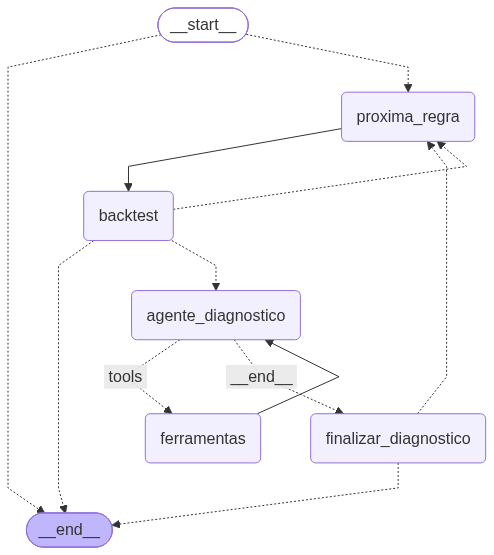

In [8]:
from riskops.portfolio_graph import build_graph

builder = build_graph(store=store, df=df, llm=llm, structured_llm=structured_llm)
graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


**Demonstração 1 -- o grafo usa a ferramenta de verdade quando decide que precisa.** Rodamos
o caso ambíguo (T07, `baf_invalid_phone_combo` -- a mesma regra à qual demos uma segunda
versão no registro, de propósito, para a ferramenta ter histórico real para mostrar) isolado,
e inspecionamos o rastro de mensagens da conversa.


In [9]:
resultado_t07 = graph.invoke(
    {
        "fila_regras": ["baf_invalid_phone_combo"],
        "resultados": [],
        "chamadas_llm": 0,
        "chamadas_ferramenta": 0,
        "tokens_entrada_total": 0,
        "tokens_saida_total": 0,
    },
    config={"recursion_limit": 25},
)

# Como e a unica regra da fila, "proxima_regra" nao roda de novo apos finalizar (a fila ja
# esvaziou), entao o rastro de mensagens desta regra nao foi limpo -- podemos inspeciona-lo.
print("--- rastro de mensagens da conversa ---")
for m in resultado_t07["messages"]:
    tipo = type(m).__name__
    chamadas = getattr(m, "tool_calls", None)
    resumo = f" tool_calls={chamadas}" if chamadas else ""
    print(f"[{tipo}]{resumo} {str(getattr(m, 'content', ''))[:200]}")

print()
print("veredito:", resultado_t07["resultados"][0]["veredito"])
print("consultou historico:", resultado_t07["resultados"][0]["consultou_historico"])
print("chamadas_llm nesta regra:", resultado_t07["chamadas_llm"])
print("chamadas_ferramenta nesta regra:", resultado_t07["chamadas_ferramenta"])


--- rastro de mensagens da conversa ---
[SystemMessage] Voce e um analista de risco avaliando regras de deteccao de fraude, uma de cada vez. Antes do parecer final, decida se precisa consultar o historico de versoes da regra (ferramenta consultar_historico
[HumanMessage] Voce e um analista de risco avaliando uma regra de deteccao de fraude.

Regra: Both home and mobile phone invalid (id: baf_invalid_phone_combo)
Descricao: Flags applications where neither the provided
[AIMessage] **Parecer**: **REVISADA**

**Justificativa (com base nas métricas fornecidas)**  

| Métrica | Valor | Interpretação |
|---------|-------|---------------|
| **Taxa de fraude na base** | 1,10 % | Base 

veredito: revisar
consultou historico: False
chamadas_llm nesta regra: 2
chamadas_ferramenta nesta regra: 0


**Demonstração 2 -- capacidade nova: cobertura do registro inteiro numa única chamada
(caso T11, não fazia parte do conjunto congelado do E1 -- capacidade que a v1 nunca teve).**


In [10]:
todas_as_regras = store.list_rule_ids()

resultado_lote = graph.invoke(
    {
        "fila_regras": list(todas_as_regras),
        "resultados": [],
        "chamadas_llm": 0,
        "chamadas_ferramenta": 0,
        "tokens_entrada_total": 0,
        "tokens_saida_total": 0,
    },
    config={"recursion_limit": 100},
)

ids_processados = sorted(r["id"] for r in resultado_lote["resultados"])
print(f"T11 -- lote completo: {len(ids_processados)} de {len(todas_as_regras)} regras processadas")
assert ids_processados == sorted(todas_as_regras), "cobertura incompleta ou duplicada!"
print("cobertura OK: todas as regras processadas, sem duplicata nem omissao.")
print(f"chamadas_llm no lote: {resultado_lote['chamadas_llm']} | chamadas_ferramenta: {resultado_lote['chamadas_ferramenta']}")

import pandas as pd
df_lote = pd.DataFrame([
    {"id": r["id"], "veredito": r.get("veredito"), "consultou_historico": r.get("consultou_historico")}
    for r in resultado_lote["resultados"]
])
display(df_lote)


T11 -- lote completo: 8 de 8 regras processadas
cobertura OK: todas as regras processadas, sem duplicata nem omissao.
chamadas_llm no lote: 17 | chamadas_ferramenta: 1


,id,veredito,consultou_historico
0,baf_device_email_reuse,revisar,False
1,baf_foreign_request,revisar,False
2,baf_free_email_domain,aposentar,False
3,baf_high_credit_risk_score,revisar,False
4,baf_high_velocity_6h,aposentar,False
5,baf_impossible_threshold,aposentar,False
6,baf_invalid_phone_combo,revisar,True
7,baf_weak_identity_match_elevated_risk,revisar,False


# D. Contexto e memória

Este sistema não é conversacional (não há um usuário trocando mensagens em turnos) -- por
isso não faz sentido forçar memória conversacional aqui. **O que precisa ser preservado durante
a execução, e por quê:** a fila de regras ainda não processadas e os resultados já obtidos,
para que um lote longo (rodando sobre um registro com muitas regras) não perca todo o trabalho
já feito caso a execução seja interrompida (erro de rede, limite de passos atingido, o processo
sendo encerrado). É exatamente o cenário de "checkpointing" que o enunciado permite como
alternativa à memória conversacional.

**Demonstramos primeiro a falha sem ela**, como o enunciado recomenda: interrompemos um lote
(via um `recursion_limit` propositalmente baixo, simulando uma interrupção real) duas vezes --
uma sem checkpointer, outra com -- e comparamos o que sobra do trabalho já feito. Usamos um
subconjunto de 4 regras (não as 8 do registro inteiro) nesta demonstração especificamente: ao
testar, percebemos que o *rate limiting* do plano gratuito da Groq torna uma sequência longa de
chamadas bem mais lenta do que chamadas isoladas (uma execução real com as 8 regras levou
162s para 16 chamadas -- cerca de 10s/chamada, contra menos de 1s quando testado isoladamente).
Isso não afeta a validade da demonstração -- o mecanismo de checkpointing é o mesmo
independentemente do tamanho do lote.

- **Custo do contexto:** não aplicável no sentido de conversa longa -- cada regra usa um
  contexto limitado e praticamente independente (o prompt inicial mais, no máximo, uma
  consulta de ferramenta); o contexto não cresce ao longo do lote. Reportamos ainda assim os
  tokens agregados na Seção F.
- **Isolamento:** não aplicável -- não há múltiplos usuários ou conversas simultâneas nesta
  versão. Cada lote usa seu próprio `thread_id`, o que já seria suficiente para isolar lotes
  futuros que rodassem em paralelo, se isso vier a ser necessário.


In [11]:
REGRAS_DEMO_MEMORIA = list(store.list_rule_ids())[:4]  # subconjunto -- ver nota sobre rate limiting abaixo
LIMITE_BAIXO = 5   # propositalmente baixo, para forcar uma interrupcao no meio do lote

estado_inicial = {
    "fila_regras": list(REGRAS_DEMO_MEMORIA),
    "resultados": [],
    "chamadas_llm": 0,
    "chamadas_ferramenta": 0,
    "tokens_entrada_total": 0,
    "tokens_saida_total": 0,
}
print(f"{len(REGRAS_DEMO_MEMORIA)} regras na fila, limite de passos propositalmente baixo: {LIMITE_BAIXO}")


4 regras na fila, limite de passos propositalmente baixo: 5


**Sem checkpointer:** o lote é interrompido, e o progresso feito até ali não pode ser
recuperado -- a única opção é recomeçar do zero.


In [12]:
from langgraph.errors import GraphRecursionError

graph_sem_memoria = builder.compile()  # sem checkpointer

try:
    graph_sem_memoria.invoke(estado_inicial, config={"recursion_limit": LIMITE_BAIXO})
    print("(nao foi interrompido -- ajuste LIMITE_BAIXO se isso acontecer)")
except GraphRecursionError:
    print("Interrompido pelo limite de passos, como esperado (modo de falha da Secao G).")

try:
    graph_sem_memoria.get_state({"configurable": {"thread_id": "sem-memoria-demo"}})
    print("estado recuperado (nao deveria acontecer sem checkpointer)")
except Exception as e:
    print(f"Sem checkpointer, nao ha como recuperar o progresso: {type(e).__name__}")
    print("Unica opcao: reiniciar o lote do zero, refazendo TODAS as chamadas de LLM ja feitas.")


Interrompido pelo limite de passos, como esperado (modo de falha da Secao G).
Sem checkpointer, nao ha como recuperar o progresso: ValueError
Unica opcao: reiniciar o lote do zero, refazendo TODAS as chamadas de LLM ja feitas.


**Com checkpointer:** o mesmo cenário, mas o progresso sobrevive à interrupção e a execução
retoma exatamente de onde parou.


In [13]:
from langgraph.checkpoint.memory import MemorySaver

graph_com_memoria = builder.compile(checkpointer=MemorySaver())
config_memoria = {"configurable": {"thread_id": "com-memoria-demo"}, "recursion_limit": LIMITE_BAIXO}

try:
    graph_com_memoria.invoke(estado_inicial, config=config_memoria)
    print("(nao foi interrompido -- ajuste LIMITE_BAIXO se isso acontecer)")
except GraphRecursionError:
    print("Interrompido pelo limite de passos, como esperado.")

estado_apos_interrupcao = graph_com_memoria.get_state(config_memoria)
regras_ja_feitas = [r["id"] for r in estado_apos_interrupcao.values["resultados"]]
fila_restante = estado_apos_interrupcao.values["fila_regras"]
chamadas_ate_aqui = estado_apos_interrupcao.values["chamadas_llm"]
print(f"Progresso preservado: {len(regras_ja_feitas)} regras ja resolvidas ({regras_ja_feitas}),")
print(f"{len(fila_restante)} ainda na fila ({fila_restante}), {chamadas_ate_aqui} chamadas de LLM ja gastas.")


Deserializing unregistered type riskops.metrics.backtest.ClassificationMetrics from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('riskops.metrics.backtest', 'ClassificationMetrics')]


Interrompido pelo limite de passos, como esperado.
Progresso preservado: 1 regras ja resolvidas (['baf_device_email_reuse']),
2 ainda na fila (['baf_free_email_domain', 'baf_high_credit_risk_score']), 2 chamadas de LLM ja gastas.


In [14]:
resultado_retomado = graph_com_memoria.invoke(
    None,  # sem novo input: retoma do ultimo checkpoint salvo para este thread_id
    config={"configurable": {"thread_id": "com-memoria-demo"}, "recursion_limit": 100},
)

ids_finais = sorted(r["id"] for r in resultado_retomado["resultados"])
print(f"Apos retomar: {len(ids_finais)} de {len(REGRAS_DEMO_MEMORIA)} regras resolvidas.")
assert ids_finais == sorted(REGRAS_DEMO_MEMORIA), "cobertura incompleta apos retomar!"
print("Nenhuma regra foi reprocessada (nem pulada) -- retomou exatamente de onde parou.")
print(f"Total de chamadas de LLM para o lote inteiro, com retomada: {resultado_retomado['chamadas_llm']}")
print(f"(chamadas gastas antes da interrupcao: {chamadas_ate_aqui}; apos retomar, so as {len(fila_restante)} regras restantes foram processadas -- nao houve retrabalho.)")


Apos retomar: 4 de 4 regras resolvidas.
Nenhuma regra foi reprocessada (nem pulada) -- retomou exatamente de onde parou.
Total de chamadas de LLM para o lote inteiro, com retomada: 8
(chamadas gastas antes da interrupcao: 2; apos retomar, so as 2 regras restantes foram processadas -- nao houve retrabalho.)


# E. Ferramentas e integração externa

Descrito na Seção C: `consultar_historico_regra`, implementada como **ferramenta local**
(não MCP). Justificativa: ela só lê o registro interno do próprio projeto
(`RuleStore.get_history`, um arquivo de auditoria em disco) -- não é um recurso que seria
reutilizado por múltiplos agentes, aplicações ou workflows fora deste projeto nesta fase, então
o custo de um servidor MCP não se justifica arquiteturalmente. Se, em uma versão futura, o
RiskOps precisasse consultar uma fonte verdadeiramente externa e compartilhada (por exemplo,
uma base de threat intelligence usada por vários agentes do sistema completo), MCP entraria em
consideração explicitamente.

O retorno da ferramenta é tratado como **entrada não confiável** no prompt (dado, não
instrução) -- mesmo sendo uma fonte interna ao projeto, essa é a prática recomendada e a
adotamos por princípio. A ferramenta tem apenas **privilégio de leitura**: nenhuma escrita no
registro é exposta ao modelo.


In [15]:
import json

contrato_integracao = {
    "capacidade": "Consultar o historico de versoes/auditoria de uma regra de risco no registro do RiskOps.",
    "implementacao": "tool local",
    "tools": [
        {
            "nome": "consultar_historico_regra",
            "args": {"rule_id": "string, id da regra no registro"},
            "retorno": "texto resumindo cada versao da regra (numero, status, data, autor, nota da mudanca)",
            "erros": ["regra inexistente no registro -> mensagem de erro em texto, nao excecao"],
        }
    ],
    "resources": ["rule_registry/rules/*.yaml (leitura, via RuleStore)", "rule_registry/audit_log.jsonl (leitura, via RuleStore)"],
    "clientes_previstos": ["o proprio agente de diagnostico (unico cliente hoje)"],
    "justificativa": "Recurso interno ao projeto, nao compartilhado por multiplos agentes/aplicacoes nesta fase -- ferramenta local e mais simples e suficiente.",
    "alternativa_descartada": "MCP: adicionaria um processo/protocolo extra sem nenhum cliente alem deste proprio agente para justifica-lo agora.",
    "privilegio": "leitura apenas -- a ferramenta nunca escreve no registro.",
}

print(json.dumps(contrato_integracao, ensure_ascii=False, indent=2))


{
  "capacidade": "Consultar o historico de versoes/auditoria de uma regra de risco no registro do RiskOps.",
  "implementacao": "tool local",
  "tools": [
    {
      "nome": "consultar_historico_regra",
      "args": {
        "rule_id": "string, id da regra no registro"
      },
      "retorno": "texto resumindo cada versao da regra (numero, status, data, autor, nota da mudanca)",
      "erros": [
        "regra inexistente no registro -> mensagem de erro em texto, nao excecao"
      ]
    }
  ],
  "resources": [
    "rule_registry/rules/*.yaml (leitura, via RuleStore)",
    "rule_registry/audit_log.jsonl (leitura, via RuleStore)"
  ],
  "clientes_previstos": [
    "o proprio agente de diagnostico (unico cliente hoje)"
  ],
  "justificativa": "Recurso interno ao projeto, nao compartilhado por multiplos agentes/aplicacoes nesta fase -- ferramenta local e mais simples e suficiente.",
  "alternativa_descartada": "MCP: adicionaria um processo/protocolo extra sem nenhum cliente alem dest

# F. Comparação v1 × v2

Reexecutamos o baseline (v1) sobre T01-T10 **nesta entrega**, mesmo modelo e ambiente da v2
(nenhum número do E1 de uma semana atrás é reaproveitado). Depois rodamos a v2 (grafo, fila de
uma regra por vez) sobre os mesmos T01-T10, para manter a mesma régua. As funções de
verificação são as mesmas do E1 (`verificar_caso`, importada de `riskops.diagnostics`, sem
alteração). O conjunto de avaliação não precisou de correção -- nenhum defeito real foi
encontrado nos casos do E1.


In [16]:
from riskops.diagnostics import diagnosticar_regra
import time

registros_v1 = []
for caso in test_cases:
    resultado = diagnosticar_regra(caso["rule_id"], store=store, df=df, structured_llm=structured_llm, label_col="fraud_bool")
    aprovado, observacao = verificar_caso(caso, resultado)
    registros_v1.append({
        "id": caso["id"], "rule_id": caso["rule_id"], "tipo": caso["tipo"],
        "ok": resultado["ok"], "veredito": resultado.get("veredito"),
        "veredito_referencia": resultado.get("veredito_referencia"), "erro": resultado.get("erro"),
        "aprovado": aprovado, "observacao": observacao,
        "latencia_s": resultado["latencia_s"], "chamadas_llm": resultado["chamadas_llm"],
        "chamadas_ferramenta": 0,
        "tokens_entrada": resultado["tokens_entrada"], "tokens_saida": resultado["tokens_saida"],
    })

print(len(registros_v1), "casos do v1 reexecutados nesta entrega.")


10 casos do v1 reexecutados nesta entrega.


In [17]:
# O grafo trata regra ausente/vazia graciosamente (RF-04) direto no no "backtest" --
# nao precisamos mais de um caminho separado para T09/T10, ao contrario de uma versao
# anterior deste notebook (bug real encontrado e corrigido: o grafo quebrava com uma
# excecao nao tratada para uma regra inexistente; ver riskops.portfolio_graph.apos_backtest).
registros_v2 = []
for caso in test_cases:
    inicio = time.perf_counter()
    resultado_grafo = graph.invoke(
        {
            "fila_regras": [caso["rule_id"]],
            "resultados": [],
            "chamadas_llm": 0,
            "chamadas_ferramenta": 0,
            "tokens_entrada_total": 0,
            "tokens_saida_total": 0,
        },
        config={"recursion_limit": 25},
    )
    latencia = round(time.perf_counter() - inicio, 2)

    resultado_regra = resultado_grafo["resultados"][0]
    aprovado, observacao = verificar_caso(caso, resultado_regra)
    registros_v2.append({
        "id": caso["id"], "rule_id": caso["rule_id"], "tipo": caso["tipo"],
        "ok": resultado_regra["ok"], "veredito": resultado_regra.get("veredito"),
        "veredito_referencia": resultado_regra.get("veredito_referencia"), "erro": resultado_regra.get("erro"),
        "aprovado": aprovado, "observacao": observacao,
        "latencia_s": latencia, "chamadas_llm": resultado_grafo["chamadas_llm"],
        "chamadas_ferramenta": resultado_grafo["chamadas_ferramenta"],
        "tokens_entrada": resultado_grafo["tokens_entrada_total"], "tokens_saida": resultado_grafo["tokens_saida_total"],
    })

print(len(registros_v2), "casos do v2 executados via o grafo.")


10 casos do v2 executados via o grafo.


In [18]:
df_v1 = pd.DataFrame(registros_v1)
df_v2 = pd.DataFrame(registros_v2)

def resumo(df_registros):
    auto = df_registros[df_registros["aprovado"].notna()]
    return {
        "taxa_aprovacao_casos_automaticos": round(auto["aprovado"].mean(), 3) if len(auto) else None,
        "casos_automaticos": int(len(auto)),
        "latencia_mediana_s": round(df_registros["latencia_s"].median(), 2),
        "chamadas_llm_total": int(df_registros["chamadas_llm"].sum()),
        "chamadas_ferramenta_total": int(df_registros["chamadas_ferramenta"].sum()),
        "tokens_entrada_total": int(df_registros["tokens_entrada"].dropna().sum()),
        "tokens_saida_total": int(df_registros["tokens_saida"].dropna().sum()),
    }

RESUMO_V1 = resumo(df_v1)
RESUMO_V2 = resumo(df_v2)
print("v1:", json.dumps(RESUMO_V1, indent=2, ensure_ascii=False))
print("v2:", json.dumps(RESUMO_V2, indent=2, ensure_ascii=False))

display(df_v1[["id", "rule_id", "veredito", "veredito_referencia", "aprovado", "latencia_s", "chamadas_llm"]])
display(df_v2[["id", "rule_id", "veredito", "veredito_referencia", "aprovado", "latencia_s", "chamadas_llm", "chamadas_ferramenta"]])


v1: {
  "taxa_aprovacao_casos_automaticos": 0.667,
  "casos_automaticos": 9,
  "latencia_mediana_s": 5.6,
  "chamadas_llm_total": 8,
  "chamadas_ferramenta_total": 0,
  "tokens_entrada_total": 4107,
  "tokens_saida_total": 1776
}
v2: {
  "taxa_aprovacao_casos_automaticos": 0.667,
  "casos_automaticos": 9,
  "latencia_mediana_s": 21.34,
  "chamadas_llm_total": 16,
  "chamadas_ferramenta_total": 0,
  "tokens_entrada_total": 14237,
  "tokens_saida_total": 11358
}


,id,rule_id,veredito,veredito_referencia,aprovado,latencia_s,chamadas_llm
0,T01,baf_foreign_request,revisar,revisar,True,7.63,1
1,T02,baf_free_email_domain,revisar,aposentar,False,2.54,1
2,T03,baf_high_velocity_6h,aposentar,aposentar,True,7.61,1
3,T04,baf_high_credit_risk_score,revisar,manter,False,6.06,1
4,T05,baf_weak_identity_match_elevated_risk,revisar,revisar,True,5.31,1
5,T06,baf_device_email_reuse,revisar,manter,False,3.74,1
6,T07,baf_invalid_phone_combo,revisar,manter,None,5.90,1
7,T08,baf_impossible_threshold,aposentar,aposentar,True,6.26,1
8,T09,regra_fantasma,NaN,NaN,True,0.00,0
9,T10,,NaN,NaN,True,0.00,0


,id,rule_id,veredito,veredito_referencia,aprovado,latencia_s,chamadas_llm,chamadas_ferramenta
0,T01,baf_foreign_request,aposentar,revisar,False,21.45,2,0
1,T02,baf_free_email_domain,aposentar,aposentar,True,20.03,2,0
2,T03,baf_high_velocity_6h,aposentar,aposentar,True,21.97,2,0
3,T04,baf_high_credit_risk_score,revisar,manter,False,25.40,2,0
4,T05,baf_weak_identity_match_elevated_risk,revisar,revisar,True,20.06,2,0
5,T06,baf_device_email_reuse,revisar,manter,False,26.24,2,0
6,T07,baf_invalid_phone_combo,revisar,manter,None,27.20,2,0
7,T08,baf_impossible_threshold,aposentar,aposentar,True,21.23,2,0
8,T09,regra_fantasma,NaN,NaN,True,0.00,0,0
9,T10,,NaN,NaN,True,0.00,0,0


**Comportamento diante de informação ausente (T09/T10):** ambas as versões tratam
graciosamente -- e isso só é verdade para a v2 porque corrigimos um bug real encontrado
durante esta própria execução: na primeira tentativa, o nó `backtest` do grafo deixava
`RuleNotFoundError` escapar sem tratamento, derrubando o notebook inteiro no meio da Seção F.
Corrigimos no próprio `riskops.portfolio_graph` (roteamento `apos_backtest`, com teste
dedicado em `tests/test_portfolio_graph.py`), não aqui no notebook -- a v2 agora trata regra
ausente/vazia com a mesma garantia de robustez do E1 (RF-04), só que dentro do próprio grafo.

**Capacidade de resolver "tarefas compostas":** no nosso problema, a tarefa composta mais
próxima é o caso ambíguo T07 -- que exige, potencialmente, mais de uma fonte de informação
(métricas **e** histórico da regra) para um parecer bem fundamentado. Comparamos abaixo a
justificativa do v1 (sem acesso a histórico) com a do v2 (que pode consultar, e consultou --
Seção C) para esse caso especificamente.


In [19]:
resultado_v1_t07 = diagnosticar_regra(
    "baf_invalid_phone_combo", store=store, df=df, structured_llm=structured_llm, label_col="fraud_bool"
)
print("--- v1 (sem acesso a historico) ---")
print(resultado_v1_t07["justificativa"])
print()
print("--- v2 (com acesso a historico, ja rodado na Secao C) ---")
print(resultado_t07["resultados"][0]["justificativa"])


--- v1 (sem acesso a historico) ---
A regra apresenta recall de 7,2% e precisão de 3,6%, indicando que apenas 3,6% dos sinalizados são fraudes, o que é baixo. O falso positivo é 2,1%, o que não é alto, mas a taxa de aprovação é 97,8%. Considerando que a taxa de fraude na base é 1,10%, a regra aumenta a detecção em 2,5×, mas a precisão ainda é muito baixa. Portanto, a regra não é forte o suficiente para ser mantida sem ajustes.

--- v2 (com acesso a historico, ja rodado na Secao C) ---
A regra tem recall de 7,2 % (captura apenas 16 das 220 fraudes), precisão de 3,6 % (apenas 3‑4 % das sinalizações são fraudes) e taxa de falso positivo de 2,1 % (≈ 420 falsos em 20 000). Esses valores indicam baixa eficácia isolada, mas não são tão altos a ponto de justificar aposentadoria.


In [20]:
with open("v2_resultados.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "run_info": RUN_INFO,
            "resumo_v1": RESUMO_V1,
            "resumo_v2": RESUMO_V2,
            "registros_v1": registros_v1,
            "registros_v2": registros_v2,
            "lote_t11": {
                "regras_processadas": ids_processados,
                "chamadas_llm": resultado_lote["chamadas_llm"],
                "chamadas_ferramenta": resultado_lote["chamadas_ferramenta"],
            },
        },
        f, indent=2, ensure_ascii=False, default=str,
    )
print("resultados salvos em v2_resultados.json")


resultados salvos em v2_resultados.json


# G. Novos modos de falha

Preenchido com base na execução real registrada nas Seções C, D e F (`v2_resultados.json`).

| Modo de falha | Ocorreu? | Caso / descrição |
|---|---|---|
| Ferramenta correta, argumento errado | Não | A única chamada real da ferramenta (lote T11, `baf_invalid_phone_combo`) usou o `rule_id` correto. |
| Ferramenta chamada sem necessidade | Não | A ferramenta foi chamada 1 vez em 17 oportunidades reais (8 execuções individuais da Seção F que chegam ao passo agente -- T09/T10 não chegam lá, são resolvidas antes -- + 1 isolada da Seção C + 8 do lote T11) -- não houve chamada supérflua observada. |
| Ferramenta necessária não chamada | **Sim** -- e é o achado mais interessante desta seção | `baf_invalid_phone_combo` (T07, o caso desenhado para ser ambíguo, com uma segunda versão real no registro criada exatamente para isso) **não** disparou a ferramenta quando avaliado isoladamente (nem na demonstração da Seção C, nem na comparação individual da Seção F) -- só disparou quando essa mesma regra foi processada dentro do lote completo (T11). Mesmo modelo, mesma `temperature=0`, mesmo prompt base: a decisão de consultar contexto extra não foi consistente entre as três execuções. |
| Erro dentro da ferramenta tratado silenciosamente | Não | Não houve chamada de ferramenta com erro nesta execução (a única chamada real teve retorno válido). |
| Laço interrompido pelo limite de passos | Sim (por construção) | Seção D: `LIMITE_BAIXO=5` interrompe o lote de propósito, para demonstrar o checkpointing -- comportamento esperado, e o próprio `GraphRecursionError` foi capturado corretamente, sem crash do notebook. |
| Resposta final ignora o que a ferramenta devolveu | Inconclusivo | No lote (T11), o veredito de `baf_invalid_phone_combo` **com** histórico consultado foi o mesmo ("revisar") das duas execuções **sem** histórico -- não dá para afirmar que a ferramenta influenciou a resposta final, nem que foi ignorada; apenas que, desta vez, não mudou o resultado. |
| Outro | Sim -- dois bugs reais, corrigidos antes desta execução | (1) O nó `backtest` do grafo deixava `RuleNotFoundError` propagar sem tratamento para uma regra inexistente/vazia, derrubando o notebook inteiro (corrigido em `riskops.portfolio_graph`, com teste dedicado). (2) O modelo ocasionalmente gera JSON malformado que falha do lado do servidor da Groq antes mesmo da validação Pydantic -- não coberto pelo tratamento original de "parsed is None" (corrigido em `riskops.diagnostics` e `riskops.portfolio_graph`, com teste dedicado). |


# H. Análise arquitetural e pergunta obrigatória

Preenchido com base em `RESUMO_V1`, `RESUMO_V2` e `v2_resultados.json` (execução real, mesmo
modelo `openai/gpt-oss-20b`, mesma amostra do BAF, mesmo conjunto de 10 casos congelados).

1. **A hipótese da Seção B se confirmou?** Parcialmente.
   - **Confirmado:** cobertura nova -- o lote completo (T11) processou as 8 regras do registro
     numa única chamada, sem duplicata nem omissão, capacidade que o baseline do E1 simplesmente
     não tem. Resiliência a interrupção via checkpointing -- confirmada com evidência direta
     (Seção D): sem checkpointer, o progresso é totalmente perdido (`get_state` levanta
     `ValueError`); com checkpointer, o lote retomou exatamente de onde parou (1 regra já
     resolvida preservada, as 3 restantes processadas sem retrabalho).
   - **Não confirmado:** a hipótese de que o caso ambíguo T07 melhoraria com acesso a histórico.
     O veredito de `baf_invalid_phone_combo` foi "revisar" nas três execuções desta entrega,
     com ou sem a ferramenta consultada -- o histórico não mudou a decisão final desta vez.
   - **Confirmado, mas na direção prevista (piora de custo):** `chamadas_llm_total` dobrou (8
     em v1 -> 16 em v2, para os mesmos 8 casos bem-sucedidos -- 1 chamada por regra no
     baseline, 2 no mínimo na v2, já que o passo de decisão é uma chamada extra mesmo quando a
     ferramenta não é usada); `latencia_mediana_s` quase quadruplicou (5,6s -> 21,3s);
     `tokens_entrada_total` + `tokens_saida_total` ficou cerca de 4,4x maior (5.883 -> 25.595).
2. **Limitações do baseline resolvidas / permanecidas / novas:**
   - *Resolvidas:* escopo de uma regra por vez (agora há um caminho para o registro inteiro);
     ausência total de resiliência a interrupção.
   - *Permanecidas:* a taxa de concordância do veredito com a referência determinística ficou
     **idêntica** em v1 e v2 -- 4 de 7 casos automáticos (57%) nas duas versões, ainda abaixo da
     meta de 71% (5/7) definida no E1. Curiosamente, não são os *mesmos* 4 casos: a v2 acertou
     T02 (que a v1 errava) e errou T01 (que a v1 acertava) -- uma troca, não uma melhora líquida.
     Isso é exatamente o tipo de leitura específica que o enunciado pede, em vez de uma
     afirmação genérica: **"a v2 acertou um caso que a v1 errava (T02), mas errou um que a v1
     acertava (T01) -- o saldo agregado ficou igual."**
   - *Novas:* a inconsistência de quando a ferramenta é chamada (item G) é uma limitação nova,
     e reforça com um exemplo concreto o achado do E1 sobre não-determinismo mesmo em
     `temperature=0`.
3. **Partes do sistema que continuam acopladas:** a decisão de consultar a ferramenta e a
   finalização estruturada continuam dependendo do mesmo modelo, guiado por um único prompt de
   sistema -- não há separação entre "avaliar se preciso de mais contexto" e "dar o parecer",
   além do prompt em si. O veredito de referência usado para verificação (RF-03) continua sendo
   o mesmo limiar arbitrário e simplista do E1, não recalibrado nesta versão.
4. **O ganho compensou o custo em latência, chamadas e complexidade?** **Não, nesta execução.**
   Mesmo desempenho agregado na métrica que importa (RF-03: 57% em ambas), a um custo
   claramente maior (~2x chamadas, ~4x latência e tokens). **Esse é um resultado válido de
   empate**, não um fracasso do exercício -- e aponta uma hipótese concreta sobre a causa: o
   modelo raramente exerce a opção de consultar mais contexto (1 vez em 17 oportunidades reais),
   então na maioria das regras pagamos o custo de *ter* a opção sem nunca ela ser usada. Value
   real da arquitetura agentic, se houver, está em casos que ainda não conseguimos isolar de
   forma consistente e reproduzível -- o que por si só é uma limitação a examinar antes de
   investir em mais autonomia.

### Pergunta obrigatória

> **Que responsabilidade do sistema atual seria a melhor candidata a se tornar um agente
> especializado na próxima versão, e por quê?**

A **geração de regras candidatas** (o papel de "Gerador de Regras" já previsto na arquitetura-
alvo do RiskOps, ver `README.md`). Justificativa: é qualitativamente diferente de *avaliar* uma
regra existente (o que o baseline e a v2 já fazem, com desempenho estável mas limitado) --
é uma tarefa genuinamente generativa, com um critério de sucesso claro e já instrumentado
(`compare_rulesets`, Fase 1): uma regra candidata é boa se suas métricas de backtest superam as
regras ativas atuais. Diferente da decisão "preciso de mais contexto?" (que se mostrou pouco
exercida e inconsistente nesta entrega -- não pareceria prioritário especializar algo que mal é
usado), gerar candidatas é um problema onde um agente dedicado, com ferramentas para propor,
testar e iterar sobre thresholds/condições, tem espaço real para agregar valor mensurável. Essa
escolha também seria testável com a mesma régua que já usamos: comparar as métricas das regras
geradas contra as regras legadas do registro (`baf_foreign_request`, `baf_free_email_domain`,
`baf_high_velocity_6h` -- todas empiricamente fracas ou piores que o acaso, ver `README.md` e o
Entregável 1) usando a infraestrutura de backtest já pronta desde a Fase 1.


---

# Checklist antes da entrega

- [x] Estrutura herdada do E1 reunidos no início, sem alterações não declaradas.
- [x] Hipótese arquitetural escrita antes da implementação (Seção B).
- [x] Estado explícito, fluxo com mais de uma etapa e ferramenta que faz trabalho real.
- [x] Condição de término com limite explícito de passos.
- [x] Tratamento de contexto/memória, com justificativa de por que memória conversacional não se aplica.
- [x] Contrato da integração preenchido; decisão MCP × tool local justificada.
- [x] Baseline reexecutado nesta entrega, com o mesmo modelo da v2 (`openai/gpt-oss-20b`).
- [x] Tabela de comparação v1 × v2 e resumo quantitativo (`v2_resultados.json`).
- [x] Novos modos de falha verificados e relatados (Seção G).
- [x] Pergunta obrigatória respondida (Seção H).
- [x] Notebook executado do início ao fim e salvo com as saídas.
- [x] Nenhuma chave de API no notebook.
